In [2]:
import kagglehub
path = kagglehub.dataset_download("ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training")

Using Colab cache for faster access to the 'cafe-sales-dirty-data-for-cleaning-training' dataset.


In [3]:
import kagglehub

path = kagglehub.dataset_download(
    "ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training"
)

Using Colab cache for faster access to the 'cafe-sales-dirty-data-for-cleaning-training' dataset.


In [68]:
import os
import matplotlib.pyplot as plt

os.listdir(path)

['dirty_cafe_sales.csv']

In [6]:
import pandas as pd

df = pd.read_csv(path + "/dirty_cafe_sales.csv")

df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [8]:
df["Total Spent"].value_counts(dropna=False).head(15)

,count
Total Spent,
6.0,979
12.0,939
3.0,930
4.0,923
20.0,746
15.0,734
8.0,677
10.0,524
2.0,497


In [11]:
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")
df["Total Spent"].dtype

dtype('float64')

In [14]:
# invalid/missing revenue values we have
df["Total Spent"].isna().sum()

np.int64(502)

In [17]:
# Remove rows where revenue is unavailable
revenue_df = df.dropna(subset=["Total Spent"])
revenue_df.shape

(9498, 8)

In [18]:
# Check invalid/missing products
revenue_df["Item"].isna().sum()
revenue_df["Item"].value_counts(dropna=False)

,count
Item,
Coffee,1115
Juice,1115
Salad,1096
Cake,1088
Sandwich,1065
Tea,1041
Cookie,1035
Smoothie,1024
UNKNOWN,322


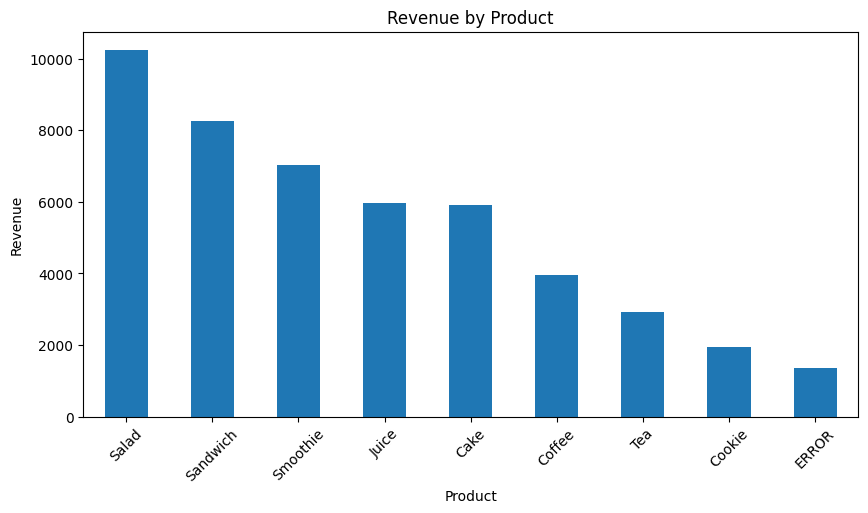

In [69]:
# Revenue by Product
revenue_by_product = (
    revenue_df.groupby("Item")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_product

# Revenue by Product — Bar Chart
revenue_by_product = (
    clean_revenue_df.groupby("Item")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_product.plot(kind="bar", figsize=(10, 5))
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [23]:
# Remove unknown/missing products
clean_revenue_df = revenue_df[
    revenue_df["Item"].notna() &
    (revenue_df["Item"] != "UNKNOWN")
]

revenue_by_product = (
    clean_revenue_df.groupby("Item")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_product

,Total Spent
Item,
Salad,16605.0
Sandwich,12956.0
Smoothie,12556.0
Juice,9984.0
Cake,9933.0
Coffee,6784.0
Tea,4735.5
Cookie,3070.0
ERROR,2453.5


In [ ]:
# Revenue by Location

In [24]:
clean_revenue_df["Location"].value_counts(dropna=False)

,count
Location,
NaN,2887
Takeaway,2675
In-store,2665
ERROR,322
UNKNOWN,305


In [26]:
#Cleaning of location column
clean_revenue_df["Location"].unique()
clean_revenue_df = clean_revenue_df[
    clean_revenue_df["Location"].isin(["Takeaway", "In-store"])
]

clean_revenue_df["Location"].value_counts(dropna=False)

,count
Location,
Takeaway,2675
In-store,2665


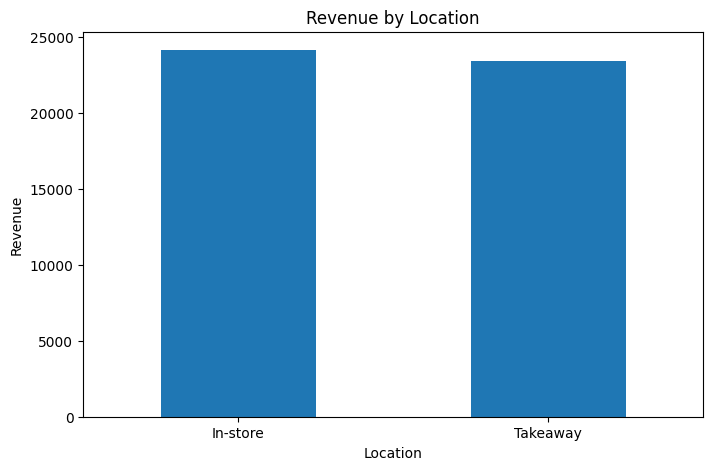

In [70]:
clean_revenue_df.groupby("Location")["Total Spent"].sum()

revenue_by_location = (
    clean_revenue_df
    .groupby("Location", as_index=False)["Total Spent"]
    .sum()
)

revenue_by_location

# Revenue by Location — Bar Chart
revenue_by_location.plot(
    x="Location",
    y="Total Spent",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Revenue by Location")
plt.xlabel("Location")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

In [29]:
# Check payment method value

In [32]:
clean_revenue_df["Payment Method"].value_counts(dropna=False)


,count
Payment Method,
NaN,1359
Digital Wallet,1278
Cash,1209
Credit Card,1204
ERROR,146
UNKNOWN,144


In [33]:
clean_revenue_df["Payment Method"].unique()

array(['Credit Card', 'Cash', 'Digital Wallet', nan, 'ERROR', 'UNKNOWN'],
      dtype=object)

In [36]:
revenue_by_payment = (
    clean_revenue_df
    .groupby("Payment Method", as_index=False)["Total Spent"]
    .sum()
)

revenue_by_payment

,Payment Method,Total Spent
0,Cash,10882.5
1,Credit Card,10678.5
2,Digital Wallet,11470.5
3,ERROR,1300.0
4,UNKNOWN,1192.5


In [ ]:
# Weekend vs Weekday Sales

In [37]:
clean_revenue_df["Transaction Date"].head()

,Transaction Date
0,2023-09-08
1,2023-05-16
4,2023-06-11
9,2023-12-31
10,2023-11-07


In [38]:
# Convert Transaction Date to datetime
clean_revenue_df["Transaction Date"] = pd.to_datetime(
    clean_revenue_df["Transaction Date"],
    errors="coerce"
)

clean_revenue_df["Transaction Date"].dtype

dtype('<M8[ns]')

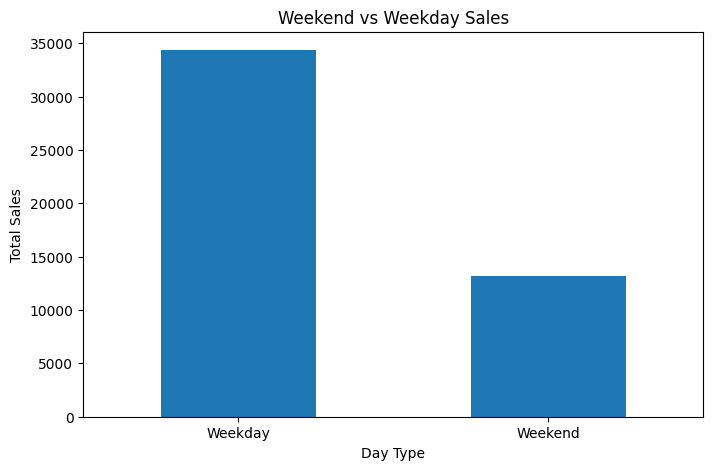

In [71]:
clean_revenue_df["Day Type"] = clean_revenue_df["Transaction Date"].dt.dayofweek.map(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

#canculating the sales
weekend_weekday_sales = (
    clean_revenue_df
    .groupby("Day Type")["Total Spent"]
    .sum()
)

weekend_weekday_sales

# Weekend vs Weekday Sales — Bar Chart

weekend_weekday_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Weekend vs Weekday Sales")
plt.xlabel("Day Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Peak Sales Day

In [42]:
sales_by_day = (
    clean_revenue_df
    .groupby(clean_revenue_df["Transaction Date"].dt.day_name())["Total Spent"]
    .sum()
)

sales_by_day

,Total Spent
Transaction Date,
Friday,6488.0
Monday,6491.5
Saturday,6401.0
Sunday,6825.0
Thursday,6939.5
Tuesday,6339.5
Wednesday,5931.5


In [43]:
#Finding peak sales day
sales_by_day.idxmax()

'Thursday'

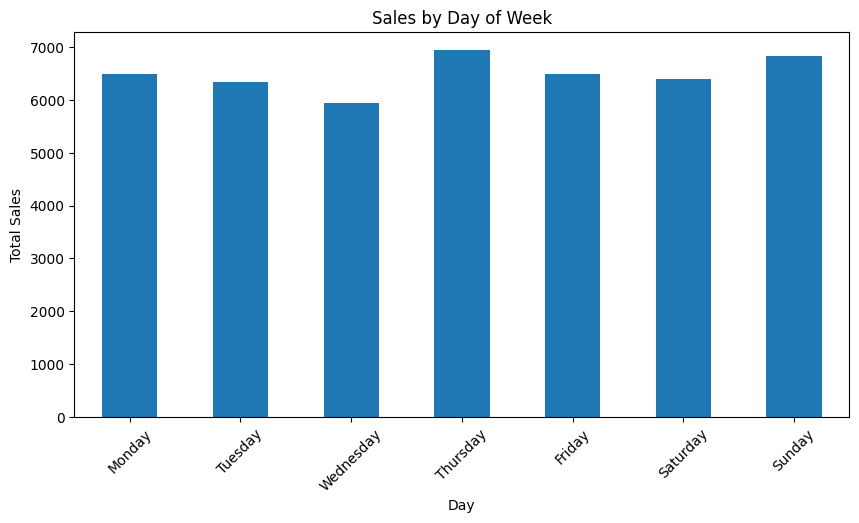

In [72]:
# Best Selling Item (by Quantity)

quantity_by_item = (
    clean_revenue_df
    .groupby("Item")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

quantity_by_item

# Peak sale Day - Bar Chart
sales_by_day = sales_by_day.reindex([
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
])

sales_by_day.plot(kind="bar", figsize=(10, 5))

plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [45]:
# Find the best-selling item
quantity_by_item.idxmax()

'Smoothie'

In [ ]:
# Product Revenue Contribution (%)


In [48]:
# Calculate revenue by product
revenue_by_product = (
    clean_revenue_df
    .groupby("Item")["Total Spent"]
    .sum()
)

# Calculate the percentage contribution
product_revenue_contribution = (
    revenue_by_product / revenue_by_product.sum() * 100
).sort_values(ascending=False)

product_revenue_contribution

,Total Spent
Item,
Salad,21.522100
Sandwich,17.352193
Smoothie,14.779630
Juice,12.522331
Cake,12.402531
Coffee,8.339814
Tea,6.125602
Cookie,4.098447
ERROR,2.857353


In [ ]:
# Transaction Success Rate

In [64]:
clean_revenue_df.columns
clean_revenue_df.columns.tolist()
[col for col in clean_revenue_df.columns if "status" in col.lower() or "payment" in col.lower()]
clean_revenue_df.head()
clean_revenue_df.shape
print(clean_revenue_df.columns.tolist())
clean_revenue_df["Transaction ID"].value_counts(dropna=False).head()

# Checkinf original data set
df.columns.tolist()

# Transaction Success Rate

transaction_success_rate = (
    clean_revenue_df["Total Spent"].notna().sum()
    / len(clean_revenue_df)
) * 100

print(f"Transaction Success Rate: {transaction_success_rate:.2f}%")


['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Day Type']
Transaction Success Rate: 100.00%


In [ ]:
# Missing Data Rate

In [60]:
# Count missing values
clean_revenue_df.isnull().sum()
#Calculate overall Missing Data Rate
missing_data_rate = (
    clean_revenue_df.isnull().sum().sum()
    / clean_revenue_df.size
) * 100

missing_data_rate

print(f"Missing Data Rate: {missing_data_rate:.2f}%")

Missing Data Rate: 3.69%


In [ ]:
# Invalid Date Percentage

In [61]:
invalid_date_percentage = (
    clean_revenue_df["Transaction Date"].isna().sum()
    / len(clean_revenue_df)
) * 100

invalid_date_percentage
print(f"Invalid Date Percentage: {invalid_date_percentage:.2f}%")

Invalid Date Percentage: 4.61%
